Last edited: 2/9/2026, 10:22 AM CST
# Nonstationary CMIP ERA5 Fit Analysis

In this notebook, I compare the results of fitting a nonstationary distribution to maximum temperature anomalies over land in ERA5.

In [22]:
# import base packages for data analysis
import numpy as np
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.transforms as mtransforms
import xesmf as xe
import cartopy.crs as ccrs
import cartopy.feature as cfeature

from scipy.stats import genextreme, describe

from config import DATA_ROOT
from src.utils import compute_ecdf

# import custom stuff
from ambpy.plotutils import make_figure_filename
plt.style.use('ambpy')

# set random attributes
np.random.seed(4)

save_figs = True

In [23]:
TMIN = 1979
GRID = '1deg'
ds_max = xr.open_dataset(DATA_ROOT / 'ERA5' / 'gev' / f'era5_t2m_annual_max_{GRID}_landonly_gev_nonstat_TMIN{TMIN}.nc', engine='netcdf4')
ds_min = xr.open_dataset(DATA_ROOT / 'ERA5' / 'gev' / f'era5_t2m_annual_min_{GRID}_landonly_gev_nonstat_TMIN{TMIN}.nc', engine='netcdf4')

## GEV parameter maps

In [24]:
def plot_nonstat_gev_parameters(ds, anom_type, vars, suptitle=None, save_fig=True,
                                filename_args=['gev-k', 'png', 'figs']):
    """
    Plot four xarray DataArrays (shape, loc, scale, k) on a 2x2 world map grid.

    Parameters
    ----------
    shape, loc, scale, k : xr.DataArray
        2D DataArrays with coordinates (lat, lon)
    titles : list or tuple of str, optional
        Custom titles for the subplots. Defaults to ['Shape', 'Location', 'Scale', 'k'].
    save_fig : bool, optional
        If True, saves the figure to `fname`.
    fname : str, optional
        Output filename if save_fig=True.
    """

    # Set up the 2x2 grid
    fig, axes = plt.subplot_mosaic(
        [
            ['A', 'B'],
            ['C', 'D'],
            ['E', 'F']
        ],
        figsize=(14, 14),
        subplot_kw={'projection': ccrs.PlateCarree()}
    )

    # adjust layout to reduce whitespace 

    das = [ds[f'loc_{anom_type}'],
           ds[f'loc_t_{anom_type}'] / len(ds.year.values) * 10.,  # convert to per decade 
           ds[f'scale_{anom_type}'],
           ds[f'scale_t_{anom_type}'] / len(ds.year.values) * 10.,  # convert to per decade 
           ds[f'shape_{anom_type}'],
           ds[f'shape_t_{anom_type}'] / len(ds.year.values) * 10.  # convert to per decade
    ]
    
    always_positive = [0, 2]

    for idx, (it, da, var) in enumerate(zip(axes.items(), das, vars)):
        lab, ax = it
        # Add map features
        ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
        ax.add_feature(cfeature.BORDERS, linewidth=0.3)
        ax.add_feature(cfeature.LAND, facecolor="lightgray", alpha=0.5)
        ax.add_feature(cfeature.OCEAN, facecolor="white")

        # Determine colormap and vmin/vmax based on parameter type
        if idx in always_positive:
            # Use sequential colormap (one half of PuOr) for always-positive parameters
            cmap = "Oranges"  # Or "YlOrBr" for consistency with orange side of PuOr
            vmin = np.nanpercentile(da.values, 5)
            vmax = np.nanpercentile(da.values, 95)
        else:
            # Use diverging colormap centered on zero for parameters that can be +/-
            cmap = "PuOr_r"
            vmax = np.nanpercentile(np.abs(da.values), 95)
            vmin = -vmax

        # Plot the parameter
        im = da.plot(
            ax=ax,
            transform=ccrs.PlateCarree(),
            cmap=cmap,
            add_colorbar=False,
            vmin=vmin,
            vmax=vmax
        )

        # Add an aligned colorbar on the right of each plot
        cbar = fig.colorbar(im, ax=ax, orientation='vertical', fraction=0.05, pad=0.04)
        cbar.set_label(var)

    # add labels
    for label, ax in axes.items():
        ax.text(0.02, 1.05, f'{label}', 
                transform=ax.transAxes,
                fontsize=14, fontweight='bold',
                va='bottom', ha='right')
        ax.set_title('')

    if suptitle is not None:
        fig.suptitle(suptitle)

    fig.subplots_adjust(left=0.05, right=0.85, top=0.55, bottom=0.02)

    if save_figs:
        fname = make_figure_filename(*filename_args)
        plt.savefig(fname, dpi=300, bbox_inches="tight")
        print(f'Figure saved to: {fname}')
    plt.show()

In [33]:
anom_type = 'raw'

Figure saved to: figs/2026-02-09-era5-t2m-max-raw-gev-nonstat-parameters-1deg-1979.png


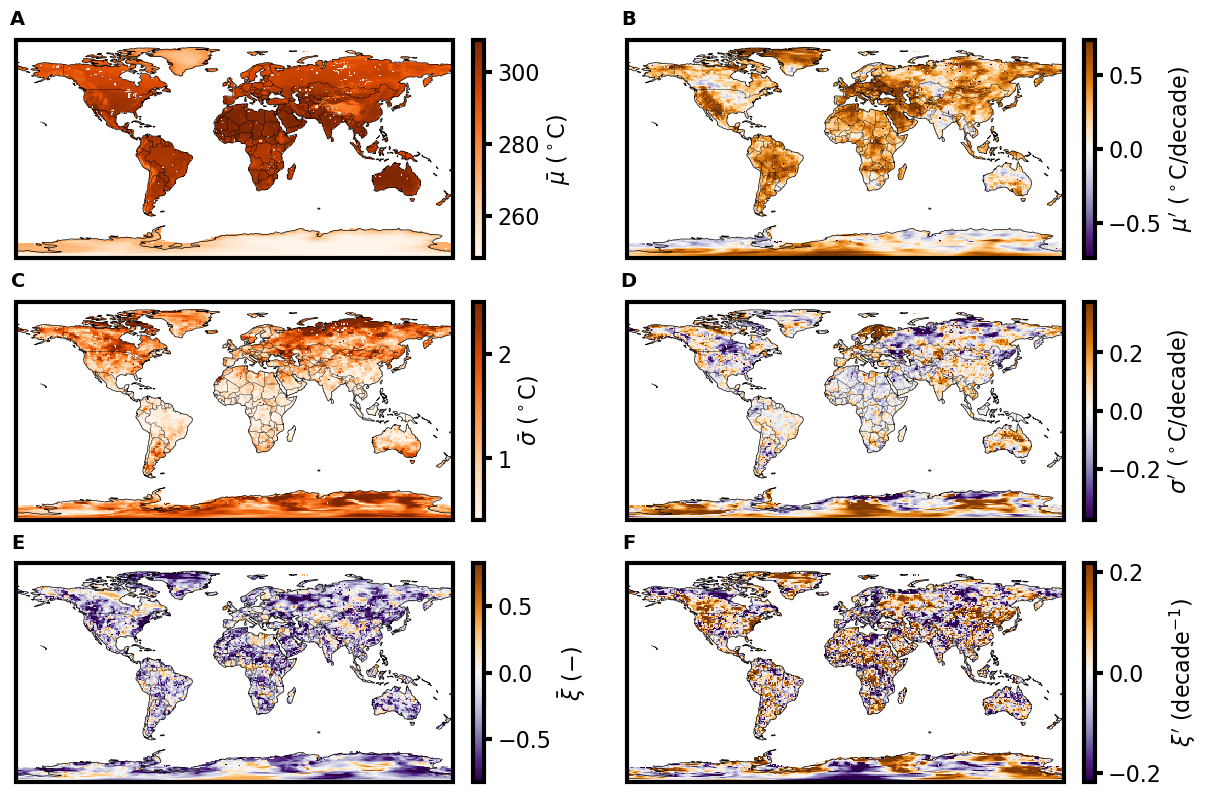

In [34]:
plot_nonstat_gev_parameters(ds_max, anom_type=anom_type,
                            vars=[r'$\bar{\mu}$ ($^\circ$C)', r"$\mu'$ ($^\circ$C/decade)", 
                                  r'$\bar{\sigma}$ ($^\circ$C)', r"$\sigma'$ ($^\circ$C/decade)", 
                                  r'$\bar{\xi}$ ($-$)', r"$\xi'$ (decade$^{-1}$)"],
                                    filename_args=[f'era5-t2m-max-{anom_type}-gev-nonstat-parameters-{GRID}-{TMIN}', 'png', 'figs'])

Figure saved to: figs/2026-02-09-era5-t2m-min-raw-gev-nonstat-parameters-1deg-1979.png


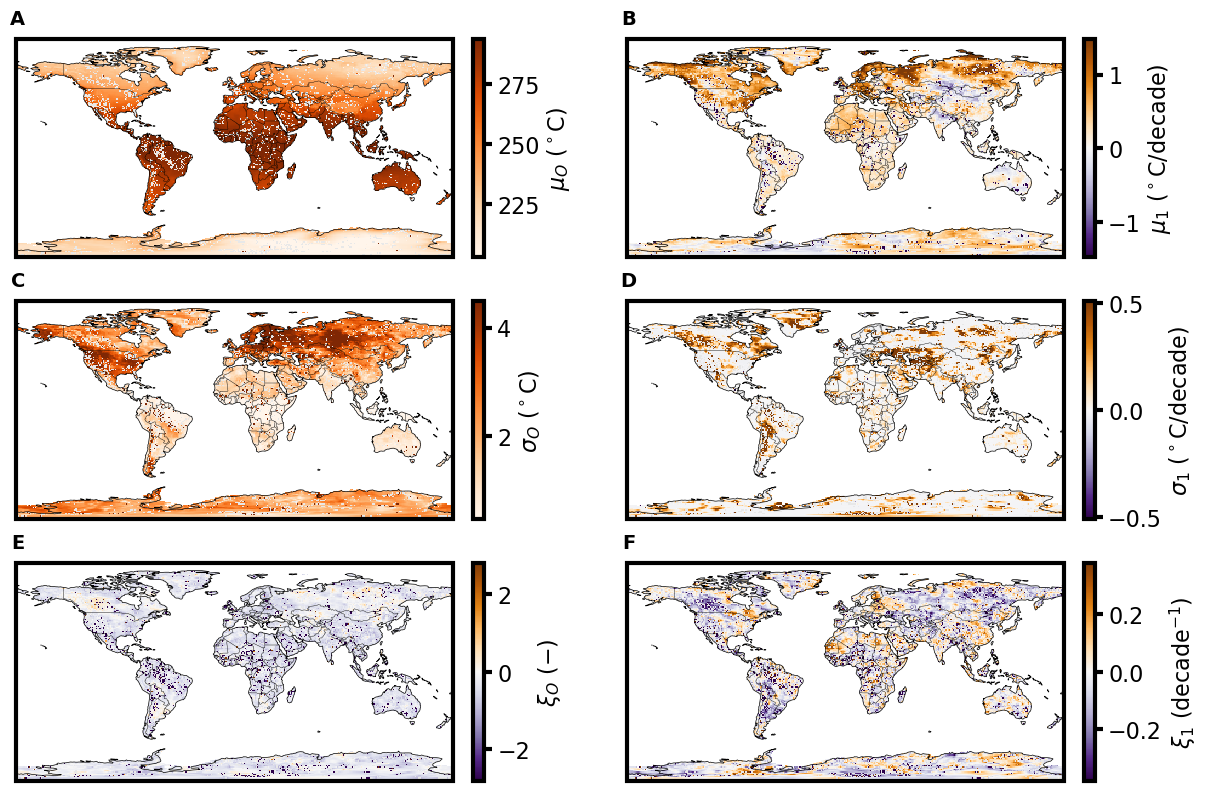

In [35]:
plot_nonstat_gev_parameters(ds_min, anom_type=anom_type,
                            vars=[r'$\mu_O$ ($^\circ$C)', r'$\mu_1$ ($^\circ$C/decade)', 
                                  r'$\sigma_O$ ($^\circ$C)', r'$\sigma_1$ ($^\circ$C/decade)', 
                                  r'$\xi_O$ ($-$)', r'$\xi_1$ (decade$^{-1}$)'],
                                    filename_args=[f'era5-t2m-min-{anom_type}-gev-nonstat-parameters-{GRID}-{TMIN}', 'png', 'figs'])